In [11]:
#import libraries
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
df_patent   = pd.read_csv("./data/tsv_specific_columns/patent.tsv",   sep="\t", dtype={"patent_id": str})

In [3]:
df_abstract = pd.read_csv("./data/tsv_specific_columns/abstract.tsv", sep="\t", dtype={"patent_id": str})


C:\Users\USER\AppData\Local\Temp\ipykernel_14452\2614174226.py:1: DtypeWarning: Columns (0: patent_abstract) have mixed types. Specify dtype option on import or set low_memory=False.
  df_abstract = pd.read_csv("./data/tsv_specific_columns/abstract.tsv", sep="\t", dtype={"patent_id": str})


In [4]:
df_inventor = pd.read_csv("./data/tsv_specific_columns/inventor.tsv", sep="\t", dtype={"patent_id": str, "inventor_id": str, "location_id": str})


In [5]:
df_location = pd.read_csv("./data/tsv_specific_columns/location.tsv", sep="\t", dtype={"location_id": str})


In [6]:
df_assignee = pd.read_csv("./data/tsv_specific_columns/assignee.tsv", sep="\t", dtype={"patent_id": str, "assignee_id": str})

### get missing values

In [7]:
print(df_patent.isnull().sum())
print(df_abstract.isnull().sum())
print(df_inventor.isnull().sum())
print(df_location.isnull().sum())
print(df_assignee.isnull().sum())

patent_id       0
patent_date     0
patent_title    0
dtype: int64
patent_id               0
patent_abstract    866158
dtype: int64
patent_id                            0
inventor_id                          0
disambig_inventor_name_first       684
disambig_inventor_name_last        540
location_id                     165581
dtype: int64
location_id          0
disambig_country    10
dtype: int64
patent_id                             0
assignee_id                           0
disambig_assignee_organization    87066
dtype: int64


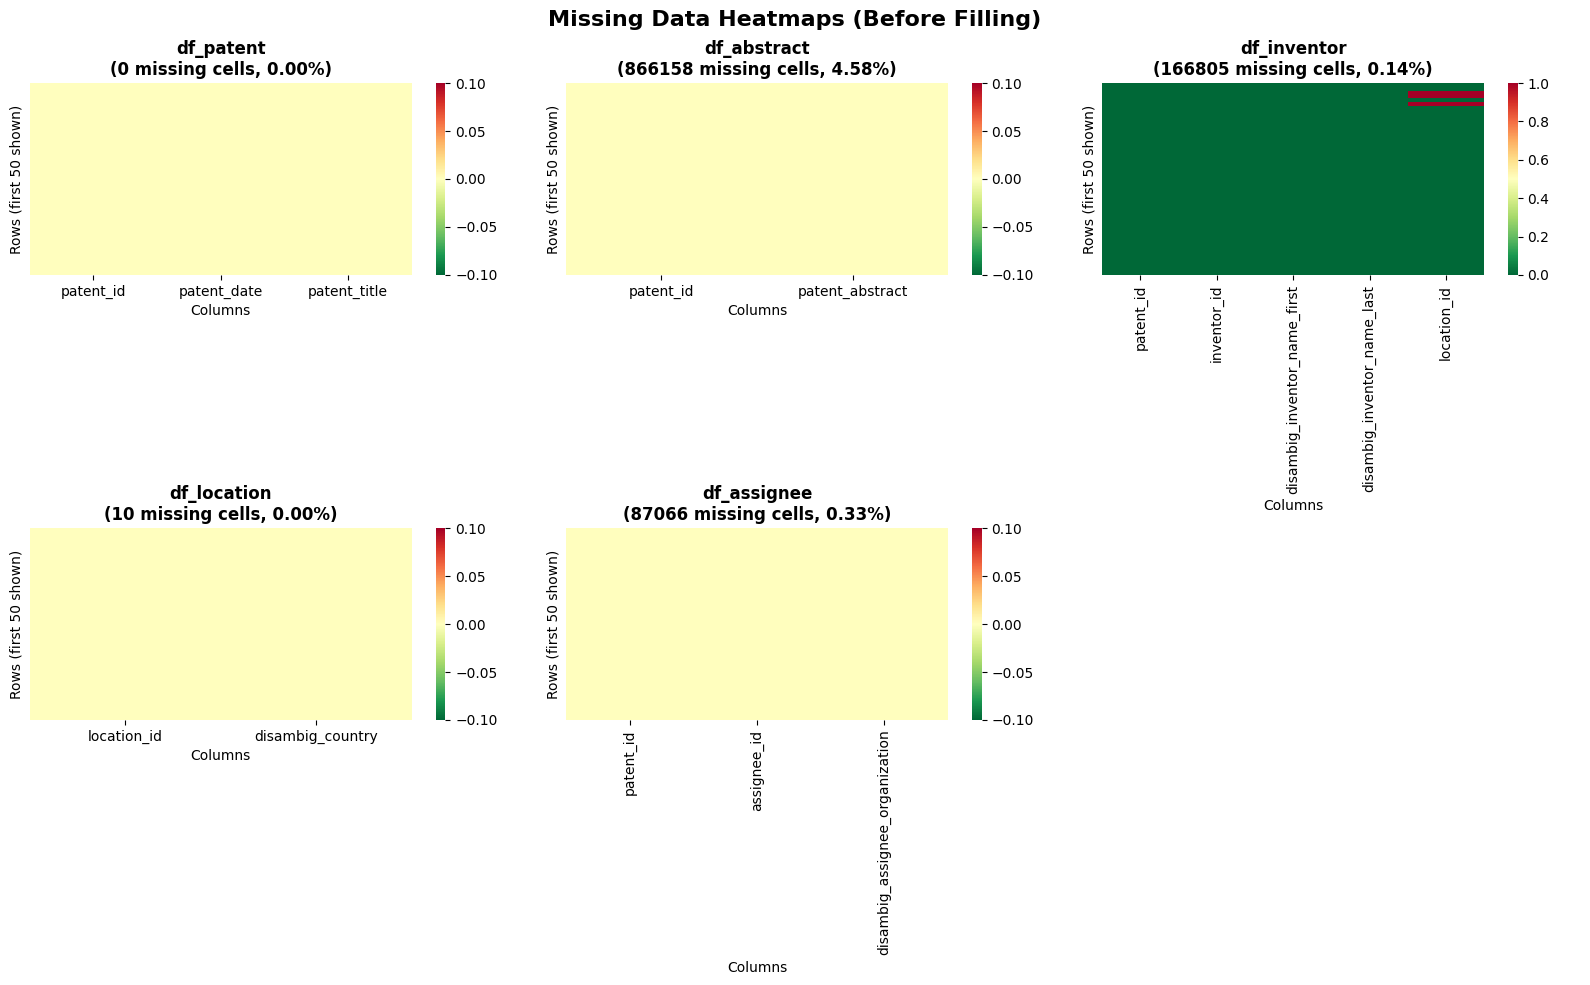

MISSING DATA(Before Filling)

df_patent:
  Total cells: 28,362,483
  Missing cells: 0
  Missing %: 0.00%
  Columns with missing values:

df_abstract:
  Total cells: 18,908,322
  Missing cells: 866158
  Missing %: 4.58%
  Columns with missing values:
    - patent_abstract: 866158 (9.16%)

df_inventor:
  Total cells: 120,186,900
  Missing cells: 166805
  Missing %: 0.14%
  Columns with missing values:
    - disambig_inventor_name_first: 684 (0.00%)
    - disambig_inventor_name_last: 540 (0.00%)
    - location_id: 165581 (0.69%)

df_location:
  Total cells: 200,904
  Missing cells: 10
  Missing %: 0.00%
  Columns with missing values:
    - disambig_country: 10 (0.01%)

df_assignee:
  Total cells: 26,253,930
  Missing cells: 87066
  Missing %: 0.33%
  Columns with missing values:
    - disambig_assignee_organization: 87066 (0.99%)


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Missing Data Heatmaps (Before Filling)', fontsize=16, fontweight='bold')

dataframes = [
    ('df_patent', df_patent),
    ('df_abstract', df_abstract),
    ('df_inventor', df_inventor),
    ('df_location', df_location),
    ('df_assignee', df_assignee)
]

for idx, (name, df) in enumerate(dataframes):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    # Create missing data indicator (1 for missing, 0 for present)
    missing_data = df.isnull().astype(int)
    sample_size = min(50, len(df))
    sns.heatmap(missing_data.iloc[:sample_size, :], 
                cbar=True, 
                cmap='RdYlGn_r',
                xticklabels=True,
                yticklabels=False,
                ax=ax)
    
    missing_count = df.isnull().sum().sum()
    total_cells = df.shape[0] * df.shape[1]
    missing_pct = (missing_count / total_cells) * 100
    
    ax.set_title(f'{name}\n({missing_count} missing cells, {missing_pct:.2f}%)', 
                 fontweight='bold')
    ax.set_xlabel('Columns')
    ax.set_ylabel('Rows (first 50 shown)')

# to hide the extra subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print("MISSING DATA(Before Filling)")
for name, df in dataframes:
    print(f"\n{name}:")
    print(f"  Total cells: {df.shape[0] * df.shape[1]:,}")
    print(f"  Missing cells: {df.isnull().sum().sum()}")
    print(f"  Missing %: {(df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100:.2f}%")
    print(f"  Columns with missing values:")
    for col in df.columns:
        missing = df[col].isnull().sum()
        if missing > 0:
            print(f"    - {col}: {missing} ({(missing/len(df))*100:.2f}%)")

### start filling

In [10]:
# Abstracts
df_abstract["patent_abstract"] = df_abstract["patent_abstract"].fillna("No abstract available")

In [11]:

# Inventors
df_inventor["disambig_inventor_name_first"] = df_inventor["disambig_inventor_name_first"].fillna("Unknown")
df_inventor["disambig_inventor_name_last"]  = df_inventor["disambig_inventor_name_last"].fillna("Unknown")
df_inventor["location_id"]                  = df_inventor["location_id"].fillna("Unknown")


In [12]:
# Locations
df_location["disambig_country"] = df_location["disambig_country"].fillna("Unknown")


In [13]:
# Assignees
df_assignee["disambig_assignee_organization"] = df_assignee["disambig_assignee_organization"].fillna("Unknown Organization")


In [14]:
# Verify no nulls remain
for name, df in [("patent", df_patent), ("abstract", df_abstract), ("inventor", df_inventor),
                  ("location", df_location), ("assignee", df_assignee)]:
    print(f"{name} nulls remaining: {df.isnull().sum().sum()}")

patent nulls remaining: 0
abstract nulls remaining: 0
inventor nulls remaining: 0
location nulls remaining: 0
assignee nulls remaining: 0


## handle duplicates


In [15]:
print("Duplicates")
print(f"patent duplicates: {df_patent.duplicated().sum()}")
print(f"abstract duplicates: {df_abstract.duplicated().sum()}")
print(f"inventor duplicates: {df_inventor.duplicated().sum()}")
print(f"location duplicates: {df_location.duplicated().sum()}")
print(f"assignee duplicates: {df_assignee.duplicated().sum()}")

Duplicates
patent duplicates: 0
abstract duplicates: 0
inventor duplicates: 1377
location duplicates: 0
assignee duplicates: 2573


### drop duplicates

In [18]:
# drop duplicates but keep the first occurrence
# inventor and assignee

#drop

df_inventor=df_inventor.drop_duplicates(keep='first')


In [19]:
df_assignee=df_assignee.drop_duplicates(keep='first')

In [20]:
print("Duplicates")
print(f"inventor duplicates: {df_inventor.duplicated().sum()}")
print(f"assignee duplicates: {df_assignee.duplicated().sum()}")

Duplicates
inventor duplicates: 0
assignee duplicates: 0


## Fixing Structural Errors

In [12]:
# --- Standardise Data Types ---

# patent_date → datetime
df_patent["patent_date"] = pd.to_datetime(df_patent["patent_date"], errors="coerce")
print("patent_date dtype:", df_patent["patent_date"].dtype)
print("Unparseable dates:", df_patent["patent_date"].isna().sum())

# Trim whitespace from all string columns
def strip_strings(df):
    str_cols = df.select_dtypes(include="object").columns
    df[str_cols] = df[str_cols].apply(lambda col: col.str.strip())
    return df

df_patent   = strip_strings(df_patent)
df_abstract = strip_strings(df_abstract)
df_inventor = strip_strings(df_inventor)
df_location = strip_strings(df_location)
df_assignee = strip_strings(df_assignee)

print("String columns trimmed ")

patent_date dtype: datetime64[us]
Unparseable dates: 0


C:\Users\USER\AppData\Local\Temp\ipykernel_14452\668043197.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes(include="object").columns
C:\Users\USER\AppData\Local\Temp\ipykernel_14452\668043197.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/mig

String columns trimmed 


In [13]:
# Structural Error Detection

# patent_id format check should be numeric strings 
invalid_patent_ids = df_patent[~df_patent["patent_id"].str.match(r"^\d+$", na=False)]
print(f"patent_id non-numeric: {len(invalid_patent_ids)}")
print(invalid_patent_ids["patent_id"].head())

# patent_date range check flag dates outside plausible range
date_min, date_max = "1990-01-01", "2025-12-31"
out_of_range_dates = df_patent[
    (df_patent["patent_date"] < date_min) | (df_patent["patent_date"] > date_max)
]
print(f"\npatent_date out of range ({date_min} to {date_max}): {len(out_of_range_dates)}")
print(out_of_range_dates["patent_date"].describe())

# Blank strings 
for name, df in [("patent", df_patent), ("abstract", df_abstract),
                 ("inventor", df_inventor), ("location", df_location),
                 ("assignee", df_assignee)]:
    str_cols = df.select_dtypes(include="object").columns
    blank_counts = {col: (df[col] == "").sum() for col in str_cols if (df[col] == "").sum() > 0}
    if blank_counts:
        print(f"\n{name} blank string counts: {blank_counts}")
    else:
        print(f"{name} no blank strings")

inventor_loc_ids   = set(df_inventor["location_id"].dropna())
location_ids_valid = set(df_location["location_id"])
orphan_locations   = inventor_loc_ids - location_ids_valid
print(f"\nInventor location_ids with no match in location table: {len(orphan_locations)}")

patent_id non-numeric: 922161
8532000    D1000000
8532001    D1000001
8532002    D1000002
8532003    D1000003
8532004    D1000004
Name: patent_id, dtype: str

patent_date out of range (1990-01-01 to 2025-12-31): 1030240
count                       1030240
mean     1983-06-22 13:03:52.331107
min             1976-01-06 00:00:00
25%             1979-11-20 00:00:00
50%             1983-11-01 00:00:00
75%             1987-03-17 00:00:00
max             1989-12-26 00:00:00
Name: patent_date, dtype: object


C:\Users\USER\AppData\Local\Temp\ipykernel_14452\1945281917.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes(include="object").columns


patent no blank strings


C:\Users\USER\AppData\Local\Temp\ipykernel_14452\1945281917.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes(include="object").columns


abstract no blank strings


C:\Users\USER\AppData\Local\Temp\ipykernel_14452\1945281917.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes(include="object").columns


inventor no blank strings
location no blank strings


C:\Users\USER\AppData\Local\Temp\ipykernel_14452\1945281917.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes(include="object").columns
C:\Users\USER\AppData\Local\Temp\ipykernel_14452\1945281917.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/m

assignee no blank strings

Inventor location_ids with no match in location table: 0


In [14]:
# --- Outlier Detection ---

# Patents per year flag years with unusually low counts (data gaps)
df_patent["patent_year"] = df_patent["patent_date"].dt.year
yearly_counts = df_patent["patent_year"].value_counts().sort_index()
print("Patents per year:\n", yearly_counts)

mean_y, std_y = yearly_counts.mean(), yearly_counts.std()
outlier_years = yearly_counts[(yearly_counts < mean_y - 3*std_y) | (yearly_counts > mean_y + 3*std_y)]
print(f"\nOutlier years (±3 std): {outlier_years.index.tolist()}")

# Inventors per patent flag unusually high counts
inventors_per_patent = df_inventor.groupby("patent_id").size()
q99 = inventors_per_patent.quantile(0.99)
high_inventor_patents = inventors_per_patent[inventors_per_patent > q99]
print(f"\nInventors per patent — 99th percentile: {q99:.0f}")
print(f"Patents above 99th pct: {len(high_inventor_patents)}")
print(high_inventor_patents.sort_values(ascending=False).head(10))

# Assignees per patent
assignees_per_patent = df_assignee.groupby("patent_id").size()
q99_a = assignees_per_patent.quantile(0.99)
high_assignee_patents = assignees_per_patent[assignees_per_patent > q99_a]
print(f"\nAssignees per patent — 99th percentile: {q99_a:.0f}")
print(f"Patents above 99th pct: {len(high_assignee_patents)}")
print(high_assignee_patents.sort_values(ascending=False).head(10))

# Abstract length outliers very short or suspiciously long
df_abstract["abstract_len"] = df_abstract["patent_abstract"].str.len()
print(f"\nAbstract length stats:\n{df_abstract['abstract_len'].describe()}")

short_abstracts = df_abstract[df_abstract["abstract_len"] < 50]
long_abstracts  = df_abstract[df_abstract["abstract_len"] > 5000]
print(f"\nVery short abstracts (<50 chars): {len(short_abstracts)}")
print(f"Very long abstracts (>5000 chars): {len(long_abstracts)}")

Patents per year:
 patent_year
1976     70941
1977     69820
1978     70586
1979     52484
1980     66212
1981     71112
1982     63292
1983     62019
1984     72689
1985     77276
1986     77050
1987     89591
1988     84449
1989    102719
1990     99275
1991    106891
1992    107540
1993    109933
1994    113723
1995    113954
1996    121811
1997    124181
1998    163265
1999    169252
2000    176192
2001    184172
2002    184494
2003    187104
2004    181413
2005    157829
2006    196489
2007    182978
2008    185260
2009    192052
2010    244599
2011    248101
2012    277285
2013    303658
2014    327014
2015    326969
2016    334674
2017    352587
2018    341104
2019    392618
2020    390572
2021    363829
2022    360417
2023    350093
2024    373852
2025    378741
Name: count, dtype: int64

Outlier years (±3 std): []

Inventors per patent — 99th percentile: 9
Patents above 99th pct: 81427
patent_id
11381445    133
10367677    133
12231284    133
12418355    130
10938497    130
11

In [15]:
# --- Fix Structural Issues ---

# Replace blank strings with NaN across all frames
for df in [df_patent, df_abstract, df_inventor, df_location, df_assignee]:
    str_cols = df.select_dtypes(include="object").columns
    df[str_cols] = df[str_cols].replace("", pd.NA)

# Drop rows where patent_date could not be parsed
bad_dates = df_patent["patent_date"].isna().sum()
print(f"Dropping {bad_dates} rows with unparseable patent_date")
df_patent = df_patent.dropna(subset=["patent_date"])

# Normalise country codes to uppercase
df_location["disambig_country"] = df_location["disambig_country"].str.upper()

# Drop the helper column if you don't need it downstream
df_abstract = df_abstract.drop(columns=["abstract_len"], errors="ignore")

print("Structural fixes applied ")

C:\Users\USER\AppData\Local\Temp\ipykernel_14452\2328724831.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes(include="object").columns
C:\Users\USER\AppData\Local\Temp\ipykernel_14452\2328724831.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/mig

Dropping 0 rows with unparseable patent_date
Structural fixes applied 
